# Model Evaluation

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import pickle
import json
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_curve
)

## Loading Data

In [2]:
# Loading data

# Loading the champion model
with open('../models/champion_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Loading test data
X_test = pd.read_parquet('../data/features/X_test.parquet')
y_test = pd.read_parquet('../data/features/y_test.parquet')['isFraud']

# Loading champion info
with open('../models/champion_info.json', 'r') as f:
    champion_info = json.load(f)

# Generating predictions for test data
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f'Model loaded: {champion_info['model']}')
print(f'Test set: {X_test.shape}')
print(f'Recorded AUC: {champion_info['auc_roc']}')

C:\Users\Nitro\AppData\Local\Temp\ipykernel_40404\2700092245.py:5: UserWarning: [22:32:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  model = pickle.load(f)


Model loaded: xgboost-tuned-v4
Test set: (118108, 109)
Recorded AUC: 0.9675


## Confusion Matrix

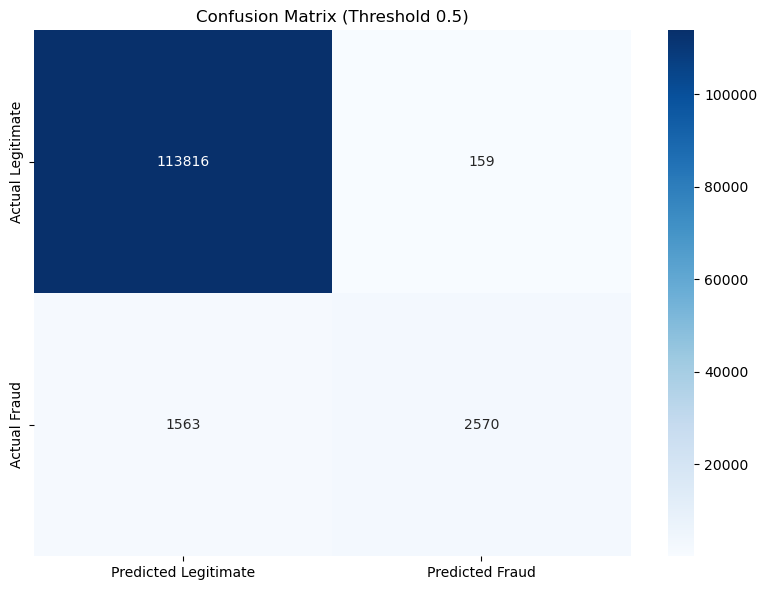

True Negatives (correctly-caught legitimate transactions): 113,816
False Positives (legitimate transactions flagged as fraud): 159
False Negatives (missed fraud transactions): 1,563
True Positives (correctly-caught fraud transactions): 2,570

Fraud transactions caught: 2570/4133 (62.2%)
False alarms: 159/113975 (0.14% of legitimate transactions)


In [3]:
# Plotting the confusion matrix at the default threshold of 0.5

y_pred = (y_pred_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title('Confusion Matrix (Threshold 0.5)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (correctly-caught legitimate transactions): {tn:,}')
print(f'False Positives (legitimate transactions flagged as fraud): {fp:,}')
print(f'False Negatives (missed fraud transactions): {fn:,}')
print(f'True Positives (correctly-caught fraud transactions): {tp:,}')
print(f'\nFraud transactions caught: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'False alarms: {fp}/{fp+tn} ({fp/(fp+tn)*100:.2f}% of legitimate transactions)')

Using the default threshold of 0.5 gives relatively decent results, but the 62.2% fraud transaction catch rate can be further improved further to increase the viability of this fraud transaction detection API.

## Finding the Optimal Threshold

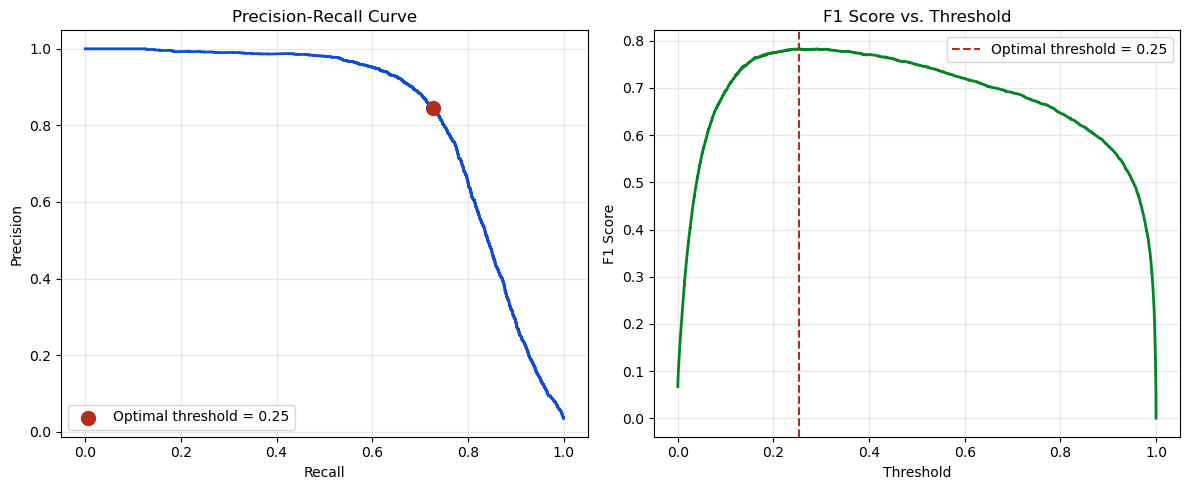

Optimal threshold (max F1):     0.2544
F1 at optimal threshold:        0.7825
Precision at optimal threshold: 0.8461
Recall at optimal threshold:    0.7278


In [4]:
# Finding the optimal threshold

# Precision-Recall curve across all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# F1 score at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = f1_scores.argmax()
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(12, 5))

# Plotting the Precision-Recall curve
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions, color="#114dce", linewidth=2)
plt.scatter(recalls[optimal_idx], precisions[optimal_idx],
            color="#b12e1f", s=100, zorder=5,
            label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)

# Plotting the F1 score across thresholds
plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores[:-1], color='#018524', linewidth=2)
plt.axvline(x=optimal_threshold, color='#b12e1f', linestyle='--',
            label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Threshold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Optimal threshold (max F1):     {optimal_threshold:.4f}')
print(f'F1 at optimal threshold:        {f1_scores[optimal_idx]:.4f}')
print(f'Precision at optimal threshold: {precisions[optimal_idx]:.4f}')
print(f'Recall at optimal threshold:    {recalls[optimal_idx]:.4f}')

While the precision saw a decrease, the recall saw a big upgrade, and the F1 score was therefore increased.

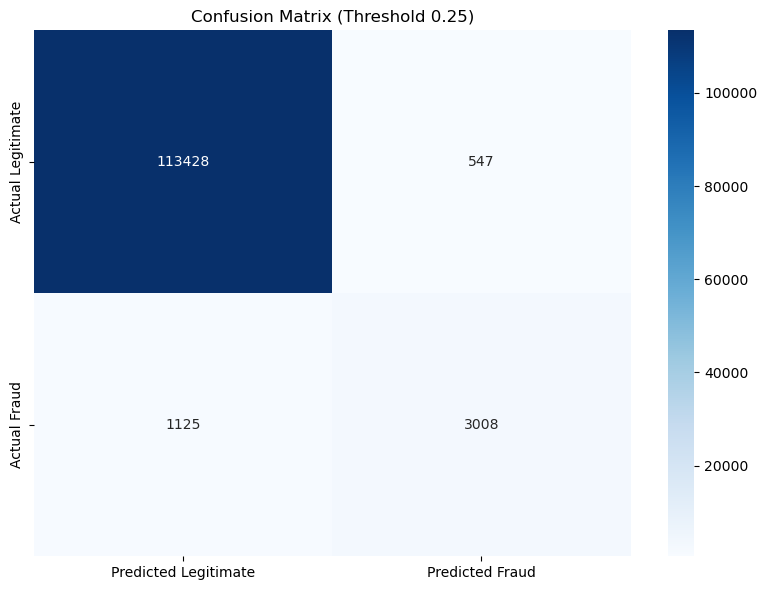

True Negatives (correctly-caught legitimate transactions): 113,428
False Positives (legitimate transactions flagged as fraud): 547
False Negatives (missed fraud transactions): 1,125
True Positives (correctly-caught fraud transactions): 3,008

Fraud transactions caught: 3008/4133 (72.8%)
False alarms: 547/113975 (0.48% of legitimate transactions)

=== Business Impact vs. Default Threshold ===
Additional fraud caught:    +438 transactions
Additional false alarms:    +388 transactions


In [5]:
# Plotting the confusion matrix at the optimal threshold

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

cm_optimal = confusion_matrix(y_test, y_pred_optimal)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'],
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title(f'Confusion Matrix (Threshold {optimal_threshold:.2f})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_optimal.ravel()
print(f'True Negatives (correctly-caught legitimate transactions): {tn:,}')
print(f'False Positives (legitimate transactions flagged as fraud): {fp:,}')
print(f'False Negatives (missed fraud transactions): {fn:,}')
print(f'True Positives (correctly-caught fraud transactions): {tp:,}')
print(f'\nFraud transactions caught: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)')
print(f'False alarms: {fp}/{fp+tn} ({fp/(fp+tn)*100:.2f}% of legitimate transactions)')

print(f'\n=== Business Impact vs. Default Threshold ===')
print(f'Additional fraud caught:    +{tp - 2570:,} transactions')
print(f'Additional false alarms:    +{fp - 159:,} transactions')

The average fraud transaction nominal is around $75, so after adjusting the threshold to ~0.25, a total of $32,850 has been saved compared to using the default threshold of 0.5. This easily justifies having more false alarms, especially as the false alarm rate is only 0.48% of legitimate transactions.

## Explainable ML with SHAP

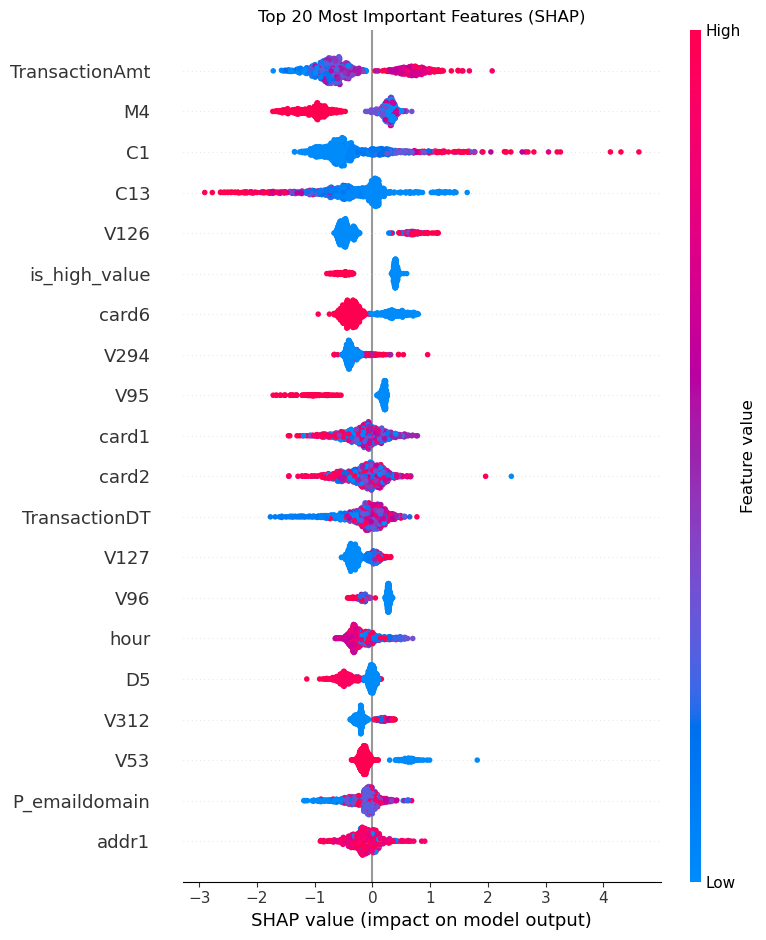

In [6]:
# Making the model explainable with SHAP

sample_size = 1000
X_sample = X_test.iloc[:sample_size]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('Top 20 Most Important Features (SHAP)')
plt.tight_layout()
plt.show()

To summarise the top 5 features, the transaction amount is a key indicator in whether a transaction is fraudulent or not, especially combined with the rest of the features. M4 is a feature that represents whether things match, so it likely indicates that mismatches are strong fraud signals. C1 and C13 are features that represent counts (such as addresses associated with the card, number of transactions in a certain time frame, and much more), indicating that card behavioural history is also a key indicator in transaction fraud detection. Lastly, V126 is a feature engineered by Vesta, the provider for the data, and it carries genuine fraud detection signals that other features do not capture.

## Updating Champion Model Info

In [7]:
# Updating champion model info

champion_info['threshold'] = float(optimal_threshold)
champion_info['threshold_f1'] = float(f1_scores[optimal_idx])
champion_info['threshold_precision'] = float(precisions[optimal_idx])
champion_info['threshold_recall'] = float(recalls[optimal_idx])
champion_info['top_features'] = ['TransactionAmt', 'M4', 'C1', 'C13', 'V126']

with open('../models/champion_info.json', 'w') as f:
    json.dump(champion_info, f, indent=2)

print('Champion info updated with optimal threshold.')
print(json.dumps(champion_info, indent=2))

Champion info updated with optimal threshold.
{
  "model": "xgboost-tuned-v4",
  "n_estimators": 2000,
  "learning_rate": 0.08,
  "auc_roc": 0.9675,
  "precision": 0.9417,
  "recall": 0.6218,
  "f1": 0.7491,
  "threshold": 0.2543548345565796,
  "threshold_f1": 0.7825182052259726,
  "threshold_precision": 0.8461322081575247,
  "threshold_recall": 0.7278006290829906,
  "top_features": [
    "TransactionAmt",
    "M4",
    "C1",
    "C13",
    "V126"
  ]
}


This concludes the model evaluation phase, which has successfully improved the model by adjusting the threshold for fraud detection, and made the model more explainable using SHAP.